<a href="https://colab.research.google.com/github/K-Tanaka8/time_series_eda_demand_forecast/blob/main/time_series_eda_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
# 時系列データのEDA（需要予測のための探索的データ分析）

# 1. ライブラリのインポート
必要なPythonライブラリを読み込みます。
- pandas, numpy: データ操作
- seaborn: 可視化
- statsmodels: 時系列解析

In [139]:
# 1 ライブラリ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.ticker as ticker

# 2. データ読み込み
- 日付と売上データを作成
- データフレームに格納し、日付をインデックスに設定

In [140]:
# 2 データ読み込み
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=180)

sales = (
    50
    + 0.2 * np.arange(180)
    + 10 * np.sin(np.arange(180)/7)
    + np.random.normal(0,3,180)
)

df = pd.DataFrame({
    "date": dates,
    "sales": sales
})

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.head()

,sales
date,
2023-01-01,51.490142
2023-01-02,51.208924
2023-01-03,55.161494
2023-01-04,59.324808
2023-01-05,55.505882


# 3. データ概要
- データの形状 (Shape)
- データ型 (Data types)
- 欠損値チェック (Missing values)
- 基本統計量 (Describe)

In [141]:
# 3 データ概要
print("Shape:", df.shape)
print()

print("Data types")
print(df.dtypes)
print()

print("Missing values")
print(df.isna().sum())
print()

print(df.describe())

Shape: (180, 1)

Data types
sales    float64
dtype: object

Missing values
sales    0
dtype: int64

            sales
count  180.000000
mean    67.882136
std     12.053933
min     43.119971
25%     58.796225
50%     67.961886
75%     76.615458
max     98.208022


# 4. 外れ値チェック
- Boxplotを使って売上データの外れ値を確認

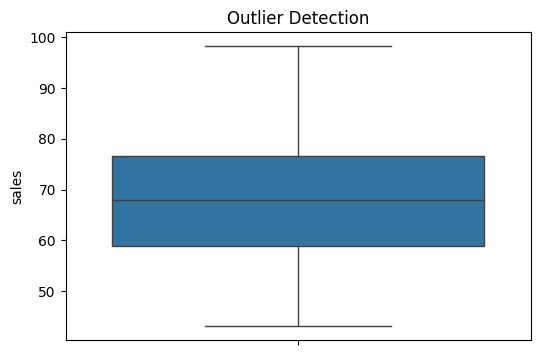

In [142]:
# 4 外れ値チェック
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(y=df["sales"], ax=ax)

ax.set_title("Outlier Detection")
plt.show()

# 5. 売上分布確認
- ヒストグラムとKDE（カーネル密度推定）で売上データの分布を可視化

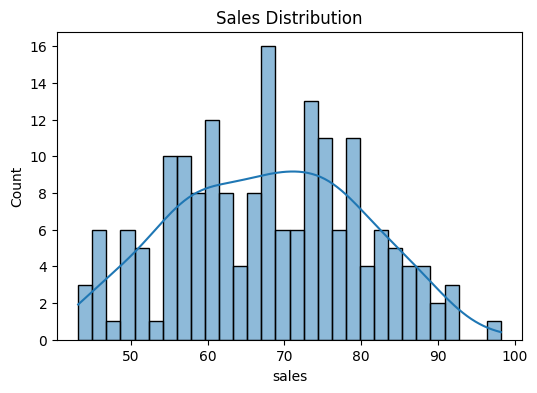

In [143]:
# 5 分布確認
fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(df["sales"], bins=30, kde=True, ax=ax)

ax.set_title("Sales Distribution")

plt.show()

# 6. 時系列プロット
- 売上の時間変化を折れ線グラフで確認
- トレンドや大きな変動の有無を視覚的に把握

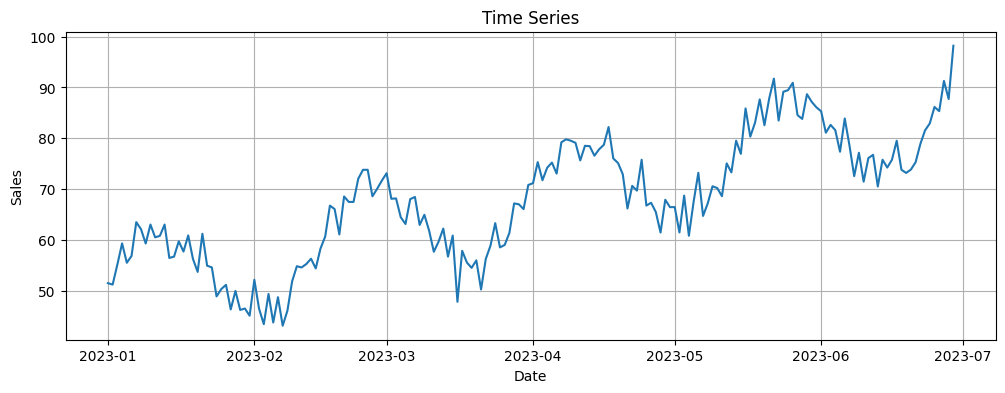

In [144]:
# 6 時系列プロット
fig, ax = plt.subplots(figsize=(12,4))

sns.lineplot(x=df.index, y=df["sales"], ax=ax)

ax.set_title("Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.grid(True)

plt.show()

# 7. 移動平均
- 7日間と30日間の移動平均を計算
- 売上と重ねてプロットし、トレンドの平滑化を確認

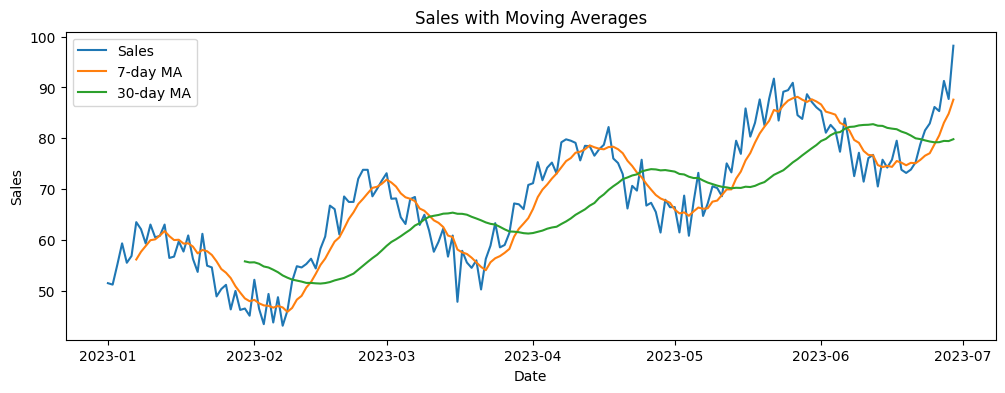

In [145]:
# 7 移動平均
df["rolling7"] = df["sales"].rolling(7).mean()
df["rolling30"] = df["sales"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12,4))

sns.lineplot(x=df.index, y=df["sales"], label="Sales", ax=ax)
sns.lineplot(x=df.index, y=df["rolling7"], label="7-day MA", ax=ax)
sns.lineplot(x=df.index, y=df["rolling30"], label="30-day MA", ax=ax)

ax.set_title("Sales with Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.show()

# 8. 曜日別売上分析
- 曜日ごとの平均売上を計算
- バープロットで曜日効果 (weekday effect) を確認

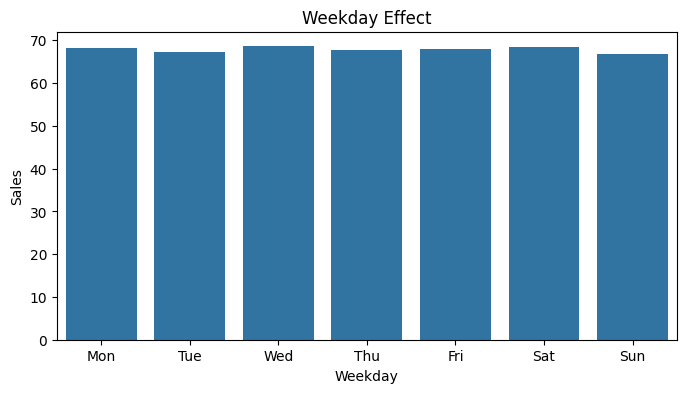

In [146]:
# 8 曜日分析
df["weekday"] = df.index.dayofweek
weekday_sales = df.groupby("weekday")["sales"].mean()

fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(x=weekday_sales.index, y=weekday_sales.values, ax=ax)

# 目盛り位置を固定してラベルを設定
ax.set_xticks(range(7))
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax.set_xticklabels(weekday_labels)

ax.set_title("Weekday Effect")
ax.set_xlabel("Weekday")
ax.set_ylabel("Sales")

plt.show()

# 9. 月別売上分析
- 月ごとの平均売上を計算
- バープロットで月次変動を確認

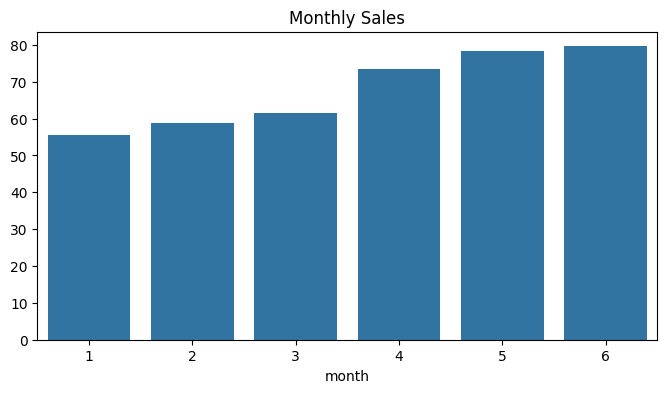

In [147]:
# 9 月別分析
df["month"] = df.index.month

month_sales = df.groupby("month")["sales"].mean()

fig, ax = plt.subplots(figsize=(8,4))


sns.barplot(
    x=month_sales.index,
    y=month_sales.values,
    ax=ax
)

ax.set_title("Monthly Sales")

plt.show()

# 10. ラグ1分析
- 前日の売上との相関を散布図で確認
- 自己相関の存在を把握

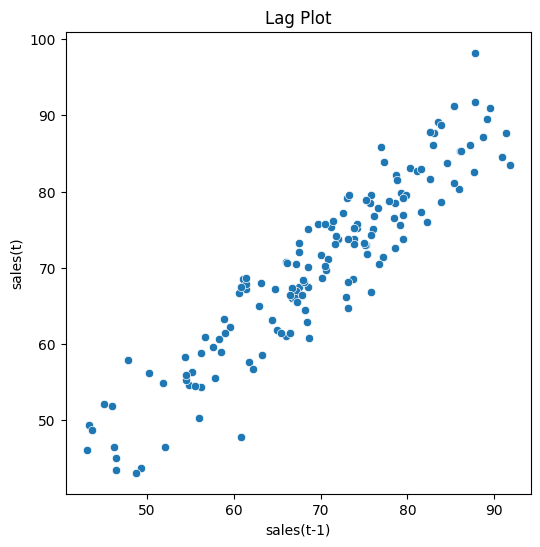

In [148]:
# 10 ラグ分析
df["lag1"] = df["sales"].shift(1)

lag_df = df.dropna()

fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(
    x="lag1",
    y="sales",
    data=lag_df,
    ax=ax
)

ax.set_xlabel("sales(t-1)")
ax.set_ylabel("sales(t)")

ax.set_title("Lag Plot")

plt.show()

# 11. 季節ラグ (Lag7) 分析
- 1週間前の売上との関係を散布図で確認
- 週次の季節性があるかを視覚化

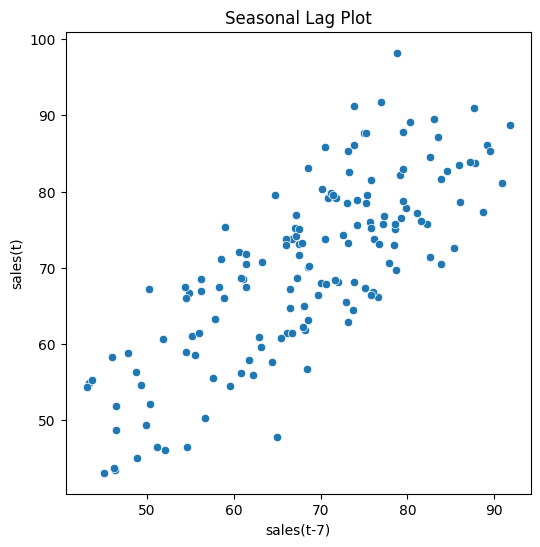

In [149]:
# 11　季節ラグ分析
df["lag7"] = df["sales"].shift(7)

lag_df = df.dropna()

fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(
    x="lag7",
    y="sales",
    data=lag_df,
    ax=ax
)

ax.set_xlabel("sales(t-7)")
ax.set_ylabel("sales(t)")

ax.set_title("Seasonal Lag Plot")

plt.show()

# 12. ラグ相関分析
- 1日～30日までの売上ラグとの相関を計算
- バープロットでラグごとの自己相関を確認

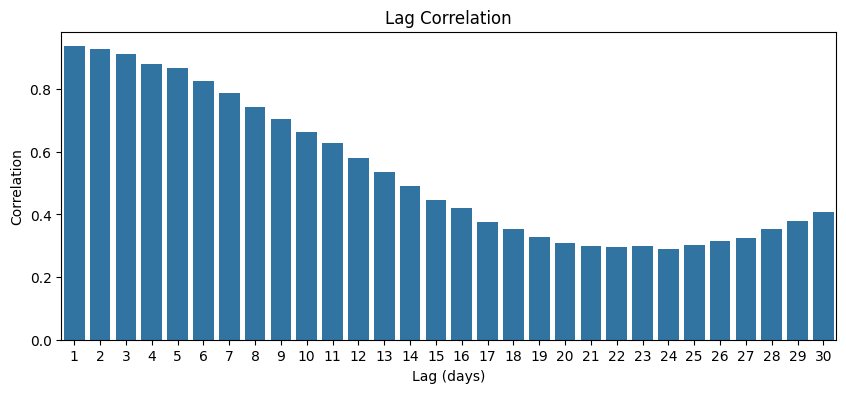

In [150]:
# 12 ラグ相関分析
lags = range(1, 31)

lag_corr = []

for lag in lags:
    corr = df["sales"].corr(df["sales"].shift(lag))
    lag_corr.append(corr)

lag_df = pd.DataFrame({
    "lag": lags,
    "correlation": lag_corr
})

plt.figure(figsize=(10,4))

sns.barplot(
    x="lag",
    y="correlation",
    data=lag_df
)

plt.title("Lag Correlation")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")

plt.show()

# 13. ACF / PACF
- 自己相関関数 (ACF) と偏自己相関関数 (PACF) をプロット
- ARIMAモデルのパラメータ設定の参考に

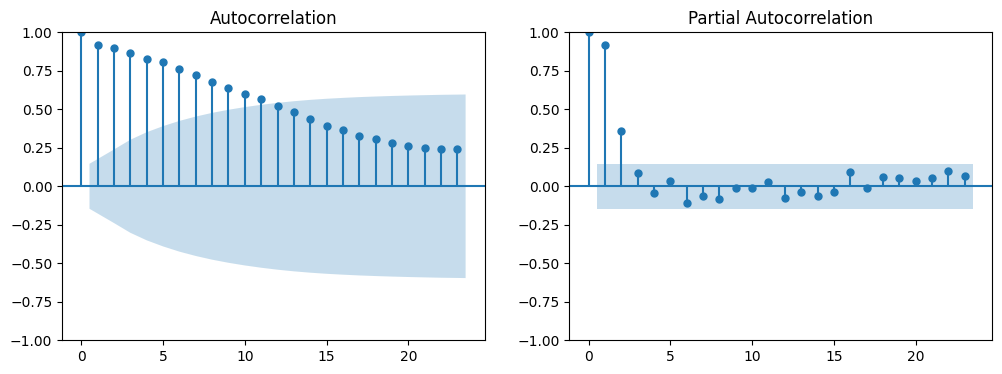

In [151]:
# 13 ACF / PACF
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(df["sales"], ax=ax[0])
plot_pacf(df["sales"], ax=ax[1])

plt.show()

# 14. 季節分解 (STL)
- 売上をトレンド・季節性・残差に分解
- 時系列の構造を詳細に把握

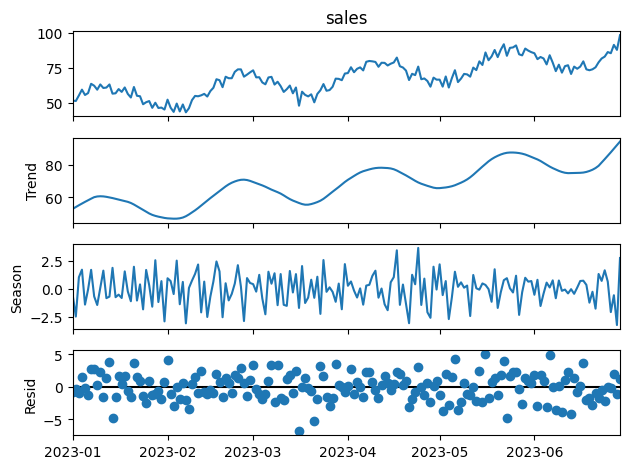

In [152]:
# 14 季節分解（STL）
from statsmodels.tsa.seasonal import STL

stl = STL(df["sales"], period=7)
res = stl.fit()

res.plot()

plt.show()

# 15. 定常性チェック（ADF検定）
- 単位根の有無を確認
- p < 0.05 → 定常, p > 0.05 → 非定常

In [153]:
# 15 定常性チェック（ADF検定）
result = adfuller(df["sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print("Critical Value (%s): %.3f" % (key, value))


# p < 0.05 → stationary
# p > 0.05 → non-stationary

ADF Statistic: -1.677634739360764
p-value: 0.4426710016157359
Critical Value (1%): -3.469
Critical Value (5%): -2.879
Critical Value (10%): -2.576


# 16. 定常性チェック（トレンドありADF検定）
- トレンド成分を考慮してADF検定
- トレンド除去後の定常性を確認

In [154]:
# 16 定常性チェック（トレンドありADF検定）
result = adfuller(df["sales"], regression="ct")

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print("Critical Value (%s): %.3f" % (key, value))

ADF Statistic: -7.055670686984738
p-value: 1.0568937874431502e-08
Critical Value (1%): -4.015
Critical Value (5%): -3.437
Critical Value (10%): -3.143


# 17. 差分による定常化
- 売上の1階差分を計算
- 差分後の時系列を可視化

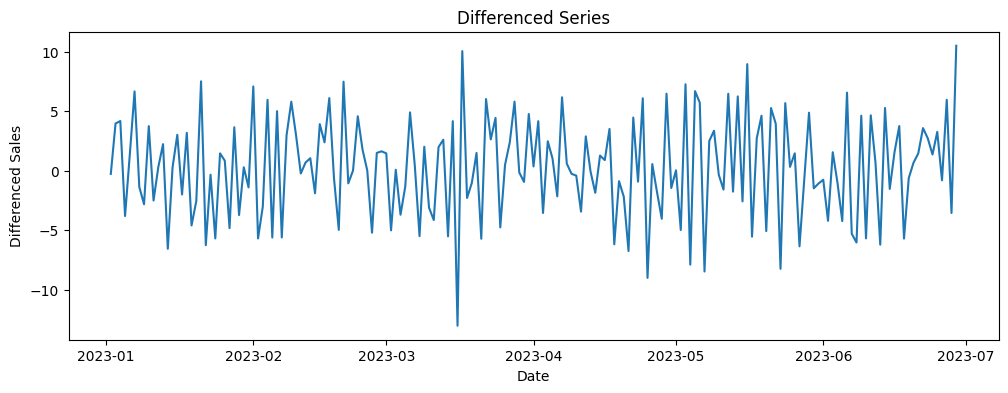

In [155]:
# 17 差分による定常化
df["sales_diff"] = df["sales"].diff()

fig, ax = plt.subplots(figsize=(12,4))

sns.lineplot(x=df.index, y=df["sales_diff"], ax=ax)

ax.set_title("Differenced Series")
ax.set_xlabel("Date")
ax.set_ylabel("Differenced Sales")

plt.show()

# 18. 差分後ADF検定
- 差分後の売上が定常か再確認

In [156]:
# 18 差分による定常化後、再度ADF検定
adf_result = adfuller(df["sales_diff"].dropna())
print("p-value:", adf_result[1])

p-value: 0.0049866721088525625


# 19. 差分後ACF / PACF
- 差分後の自己相関・偏自己相関をプロット
- ARIMAのp, d, qを決める参考

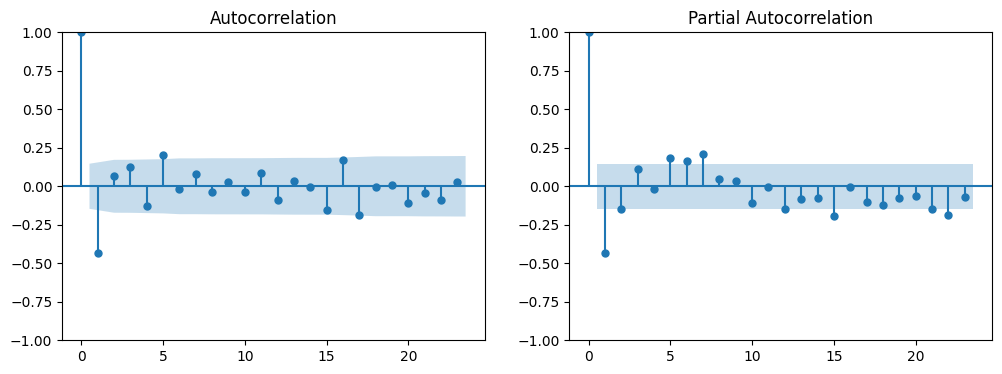

In [157]:
# 19 差分後 ACF / PACF
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(df["sales_diff"].dropna(), ax=ax[0])
plot_pacf(df["sales_diff"].dropna(), ax=ax[1])

plt.show()

In [158]:
# 20 EDAまとめ
'''
・売上は上昇トレンドあり
・週次seasonalityあり
・weekday effectあり
・外れ値なし
・non-stationary
・約7日周期の季節性あり
・曜日による売上差あり
・自己相関あり（売上は前日の売上と正の相関を持つ）
・PACF（偏自己相関）　ラグ1強く、AR(1)の可能性あり
・p < 0.05→定常ではなく、　p-value: 0.4426 > 0.05のため、帰無仮説：単位根あり（非定常）
・ADF statistic < Critical Value→定常ではなく、ADF Statistic: -1.67　>　Critical Value (5%): -2.87のため、非定常
・トレンドありADF検定による定常性チェック　p-value: 1.0568937874431502e-08 < 0.05のためトレンドを除いた残差が、帰無仮説：単位根なし（定常）
・トレンドありADF検定による定常性チェック　ADF: -7.05567　< Critical Value (5%): -3.437のためトレンドを除いた残差が定常
・差分後ACF/PACFにより、
　　ACF → q (MA次数) → Lag1強い → MA（１）
　　PACF → p (AR次数)→ Lag1強い → AR（１）

以上によりARIMA(p, d, q)
p	AR次数（自己回帰）→１（PACF）
d	差分回数　→１（1回差分取った後　p < 0.05→定常）
q	MA次数（移動平均）→０
'''

'\n・売上は上昇トレンドあり\n・週次seasonalityあり\n・weekday effectあり\n・外れ値なし\n・non-stationary\n・約7日周期の季節性あり\n・曜日による売上差あり\n・自己相関あり（売上は前日の売上と正の相関を持つ）\n・PACF（偏自己相関）\u3000ラグ1強く、AR(1)の可能性あり\n・p < 0.05→定常ではなく、\u3000p-value: 0.4426 > 0.05のため、帰無仮説：単位根あり（非定常）\n・ADF statistic < Critical Value→定常ではなく、ADF Statistic: -1.67\u3000>\u3000Critical Value (5%): -2.87のため、非定常\n・トレンドありADF検定による定常性チェック\u3000p-value: 1.0568937874431502e-08 < 0.05のためトレンドを除いた残差が、帰無仮説：単位根なし（定常）\n・トレンドありADF検定による定常性チェック\u3000ADF: -7.05567\u3000< Critical Value (5%): -3.437のためトレンドを除いた残差が定常\n・差分後ACF/PACFにより、\n\u3000\u3000ACF → q (MA次数) → Lag1強い → MA（１）  \n\u3000\u3000PACF → p (AR次数)→ Lag1強い → AR（１）\n\n以上によりARIMA(p, d, q)\u3000\np\tAR次数（自己回帰）→１（PACF）\nd\t差分回数\u3000→１（1回差分取った後\u3000p < 0.05→定常）\nq\tMA次数（移動平均）→０\n'